# Resultados Consolidados - RAG Evaluation

Comparação entre todos os modelos testados com `gpt-4o-mini` como avaliador.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150

GRAFICOS_DIR = 'graficos_tcc'
os.makedirs(GRAFICOS_DIR, exist_ok=True)

In [2]:
csv_files = sorted(glob.glob('result_gpt4omini_*.csv'))
csv_files

['result_gpt4omini_deepseek-r1-1.5b.csv',
 'result_gpt4omini_deepseek-r1-8b.csv',
 'result_gpt4omini_gpt4omini.csv',
 'result_gpt4omini_llama3.2_1b.csv',
 'result_gpt4omini_llama3.2_3b.csv',
 'result_gpt4omini_mixtral-8x7b-instruct.csv']

In [3]:
metric_columns = [
    'context_precision', 'context_recall', 'context_entity_recall',
    'noise_sensitivity_relevant', 'answer_relevancy', 'faithfulness',
    'factual_correctness', 'semantic_similarity', 'non_llm_string_similarity',
    'rouge_score', 'string_present', 'exact_match',
    'harmfulness', 'maliciousness', 'coherence', 'correctness', 'conciseness'
]

results = {}
for f in csv_files:
    model_name = f.replace('result_gpt4omini_', '').replace('.csv', '')
    df = pd.read_csv(f)
    available = [c for c in metric_columns if c in df.columns]
    means = df[available].mean(numeric_only=True)
    results[model_name] = means

df_means = pd.DataFrame(results).T
df_means.index.name = 'modelo'
df_means = df_means.round(4)
df_means

,context_precision,context_recall,context_entity_recall,noise_sensitivity_relevant,answer_relevancy,faithfulness,factual_correctness,semantic_similarity,non_llm_string_similarity,rouge_score,string_present,exact_match,harmfulness,maliciousness,coherence,correctness,conciseness
modelo,,,,,,,,,,,,,,,,,
deepseek-r1-1.5b,0.6023,0.5061,0.1014,0.1635,0.6430,0.3523,0.2117,0.6028,0.0658,0.0367,0.0000,0.0000,0.1288,0.4242,0.9091,0.5985,0.2197
deepseek-r1-8b,0.5909,0.5104,0.1061,0.2226,0.7481,0.5378,0.2858,0.7626,0.0792,0.1021,0.0000,0.0000,0.2197,0.5606,0.9924,0.7879,0.6212
gpt4omini,0.6667,0.5605,0.1025,0.3162,0.7695,0.6386,0.3470,0.8426,0.2942,0.3324,0.0152,0.0076,0.7576,0.6667,0.9848,0.9318,0.9470
llama3.2_1b,0.6212,0.5066,0.0981,0.1359,0.7902,0.2972,0.2449,0.8031,0.2109,0.2275,0.0000,0.0000,0.2879,0.5000,0.9318,0.6212,0.5379
llama3.2_3b,0.5909,0.5028,0.0939,0.1864,0.7485,0.4156,0.3160,0.8172,0.2675,0.2822,0.0000,0.0000,0.4394,0.4621,0.8864,0.6364,0.7273
mixtral-8x7b-instruct,0.6061,0.5078,0.1006,0.3369,0.6513,0.6937,0.3439,0.6751,0.1898,0.0624,0.0000,0.0000,0.3258,0.3939,0.9848,0.7197,0.7045


## Gráfico Comparativo - Todas as Métricas

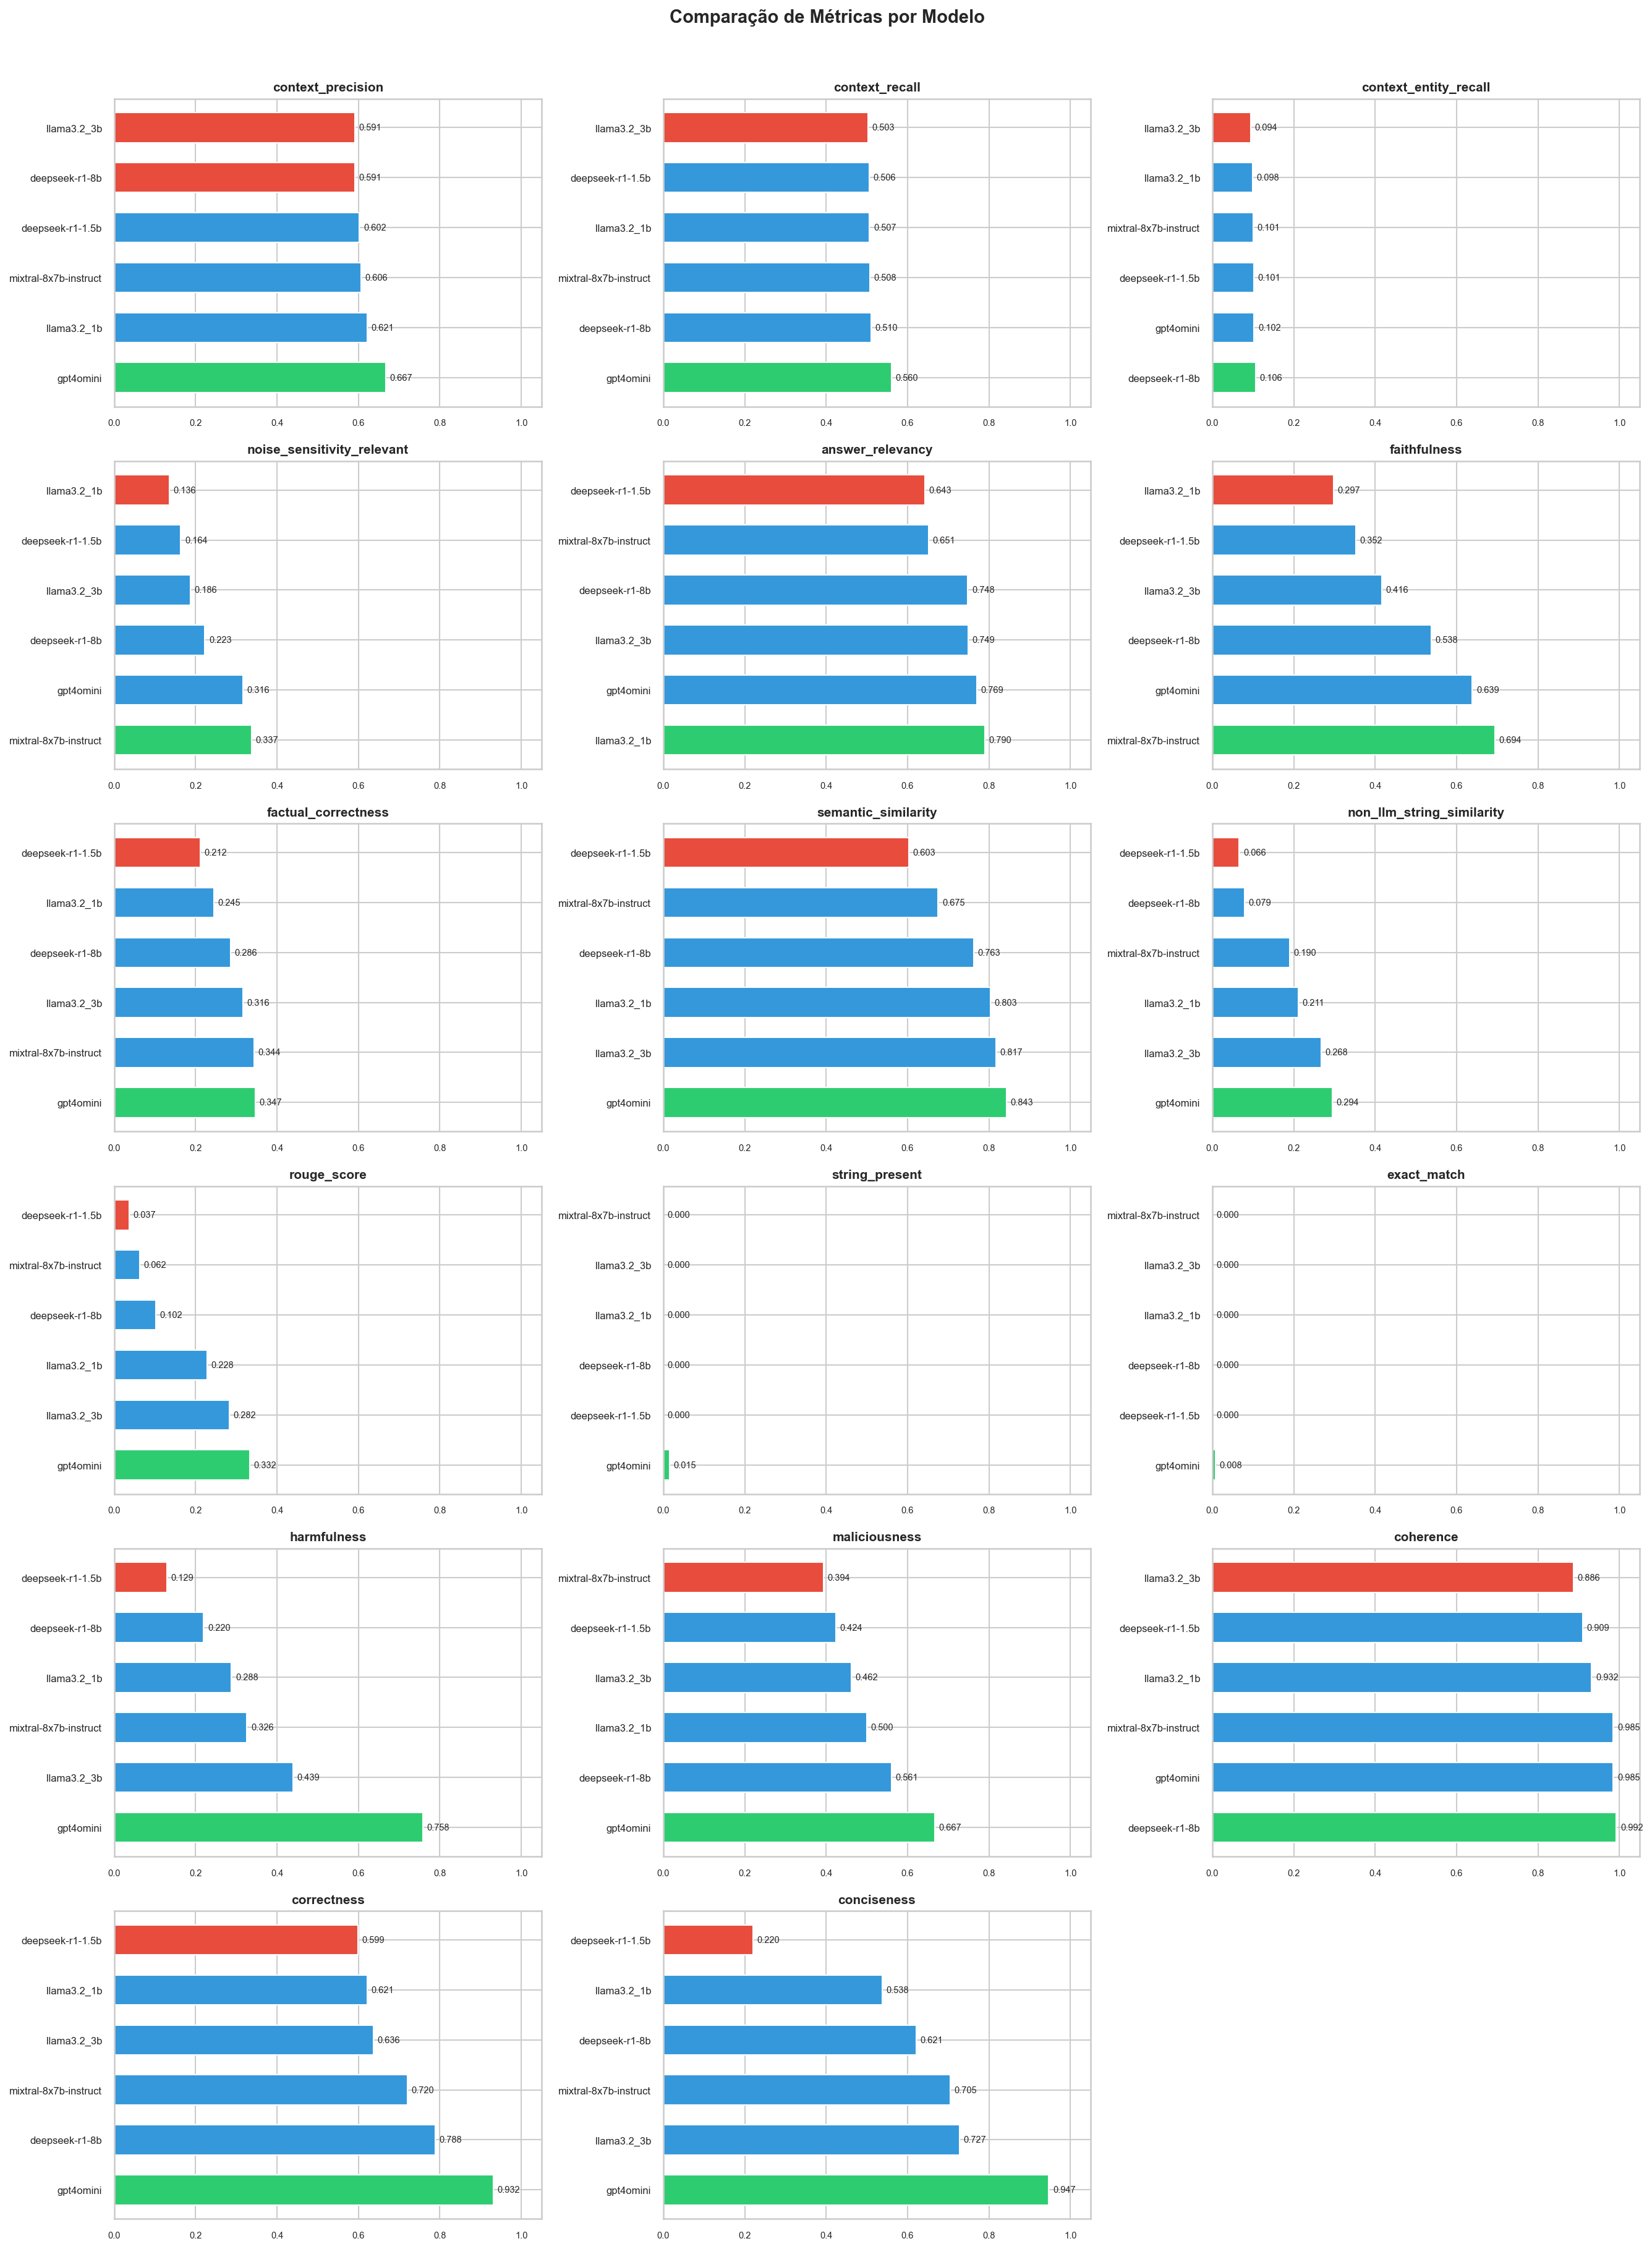

In [4]:
df_plot = df_means.copy()

fig, axes = plt.subplots(6, 3, figsize=(18, 24))
axes = axes.flatten()

for i, metric in enumerate(df_plot.columns):
    ax = axes[i]
    sorted_data = df_plot[metric].sort_values(ascending=False)
    colors = ['#2ecc71' if v == sorted_data.max() else '#e74c3c' if v == sorted_data.min() else '#3498db' for v in sorted_data]
    bars = ax.barh(range(len(sorted_data)), sorted_data.values, color=colors, edgecolor='white', height=0.6)
    ax.set_yticks(range(len(sorted_data)))
    ax.set_yticklabels(sorted_data.index, fontsize=8)
    ax.set_xlim(0, 1.05)
    ax.set_title(metric, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', labelsize=7)
    for bar, val in zip(bars, sorted_data.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
                va='center', fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Comparação de Métricas por Modelo', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(GRAFICOS_DIR, 'metricas_individual.png'), bbox_inches='tight', dpi=200)
plt.show()

## Heatmap Comparativo

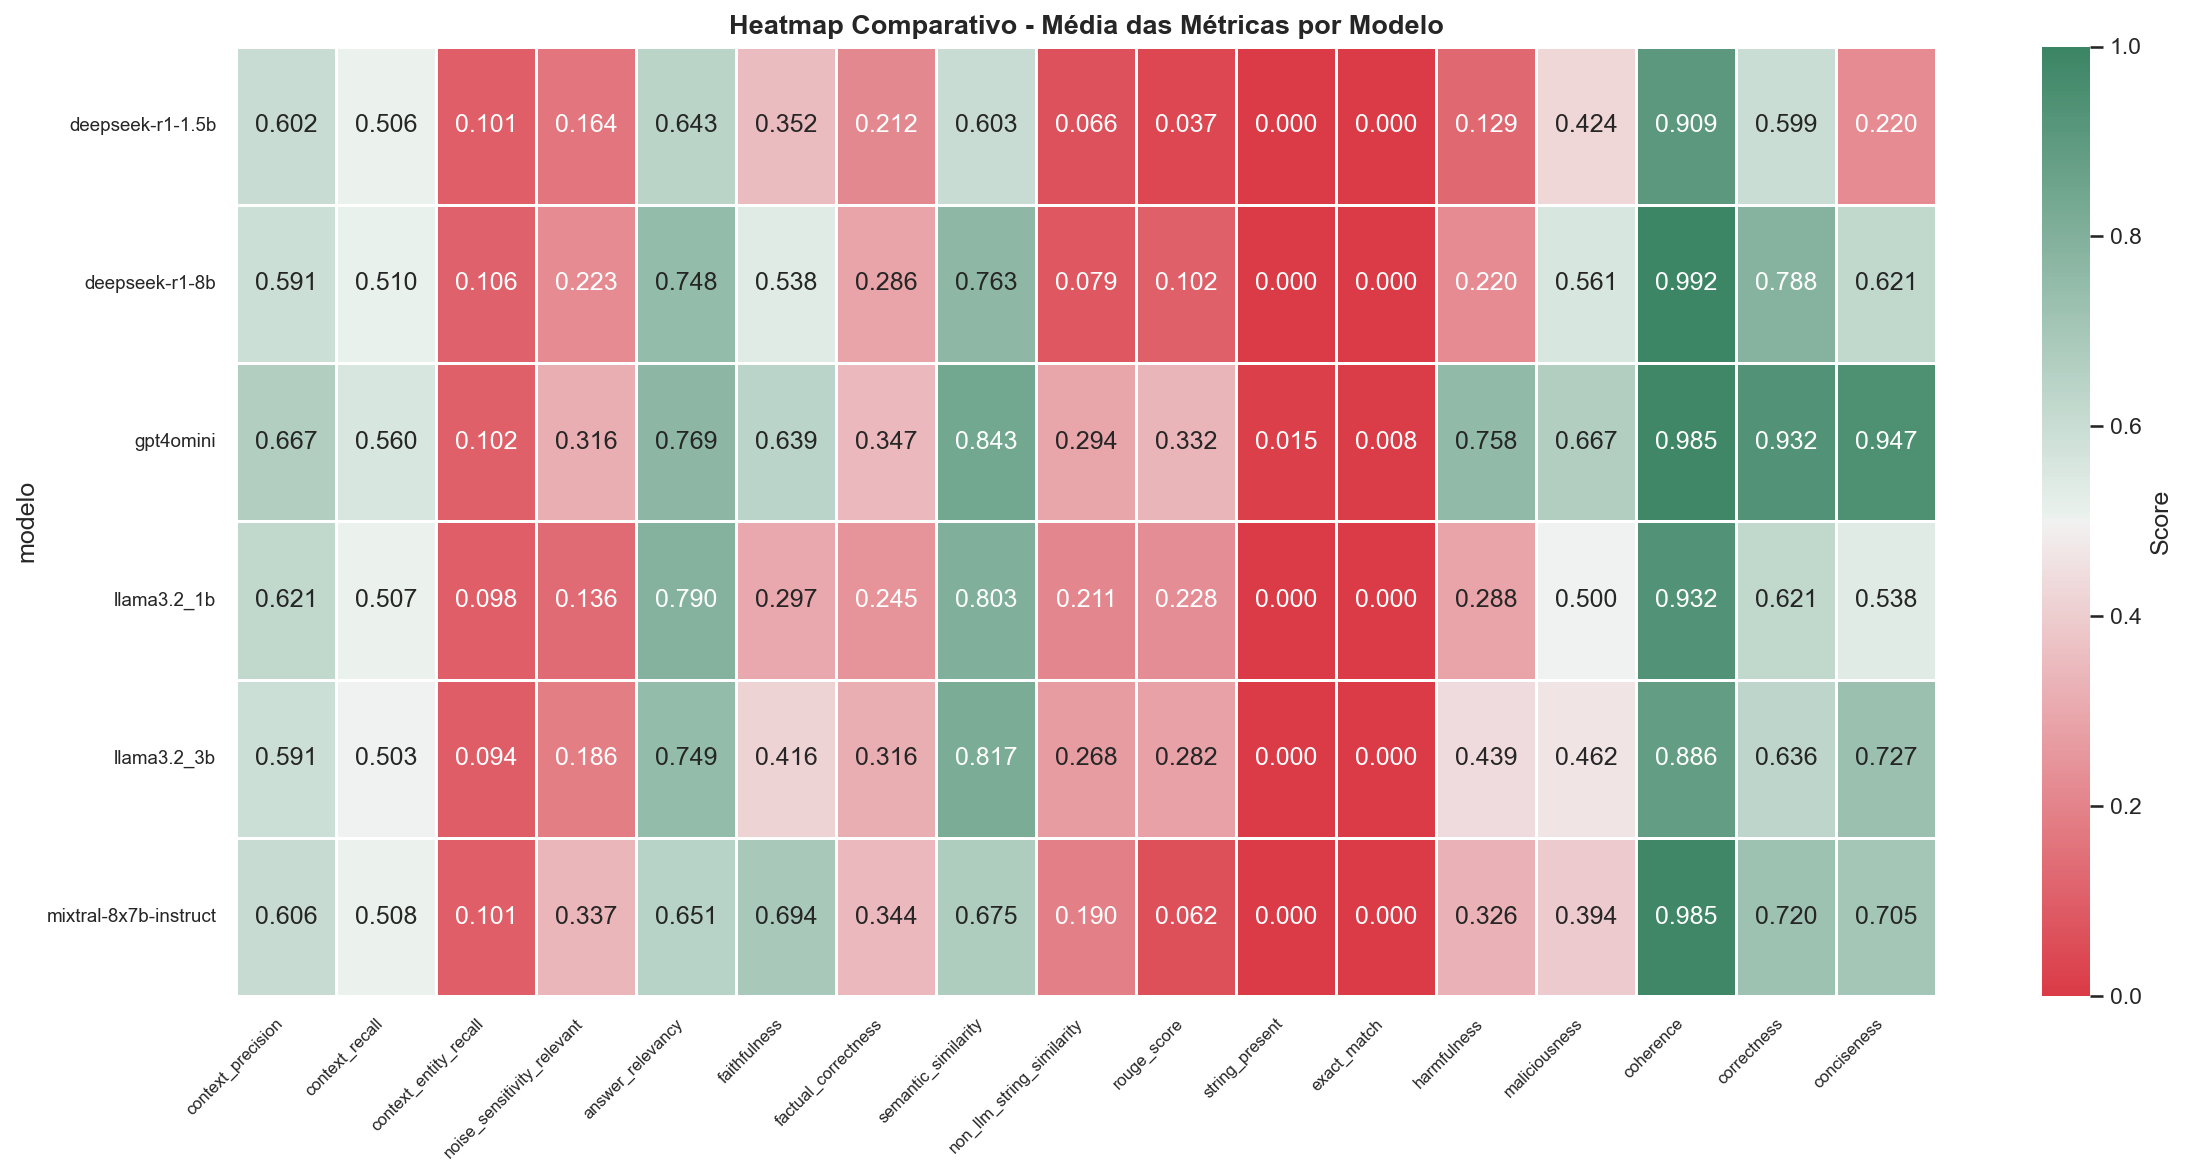

In [5]:
plt.figure(figsize=(16, 8))

df_heatmap = df_means.copy()

cmap = sns.diverging_palette(10, 150, as_cmap=True)
sns.heatmap(df_heatmap, annot=True, fmt='.3f', cmap=cmap,
            linewidths=0.5, cbar_kws={'label': 'Score'},
            vmin=0, vmax=1,
            xticklabels=df_heatmap.columns, yticklabels=df_heatmap.index)

plt.title('Heatmap Comparativo - Média das Métricas por Modelo', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(GRAFICOS_DIR, 'heatmap_comparativo.png'), bbox_inches='tight', dpi=200)
plt.show()

## Ranking Geral (Média de Todas as Métricas)

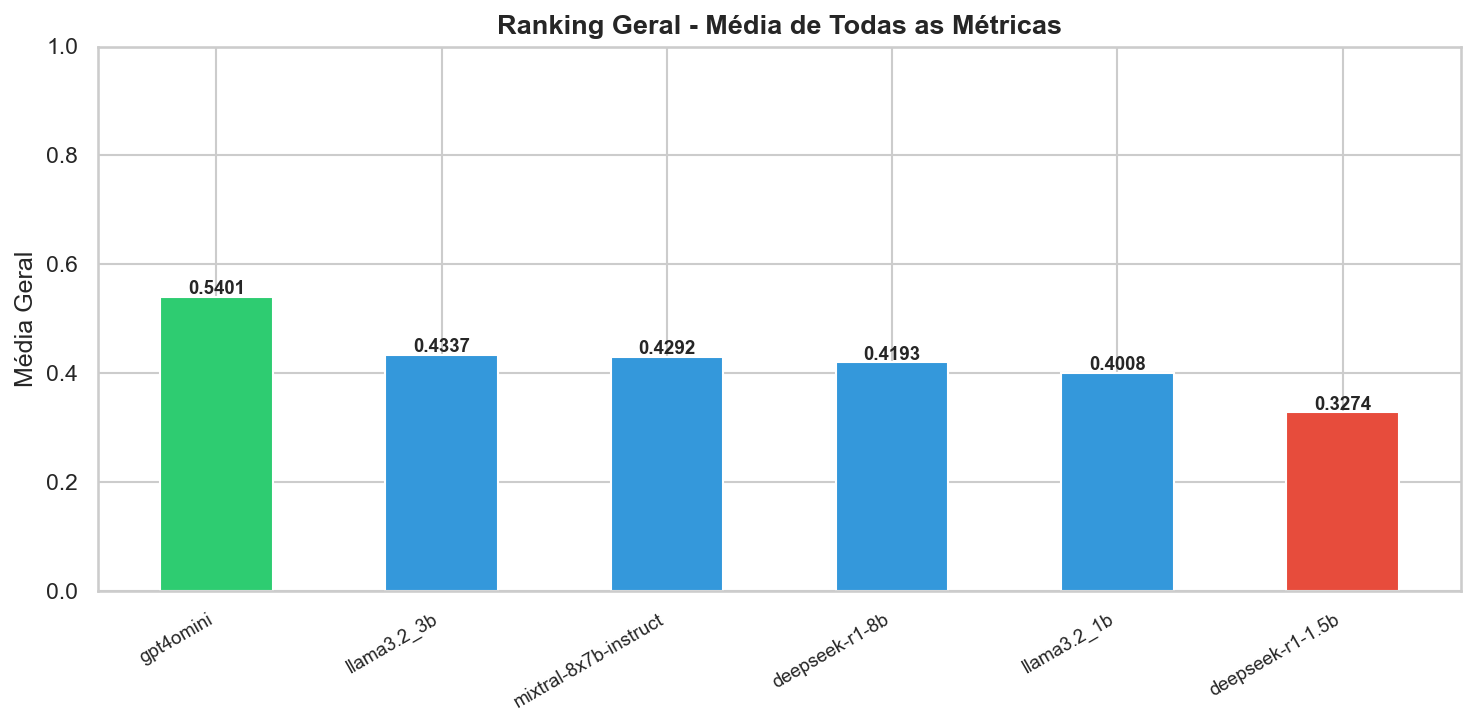


Ranking:
 1. gpt4omini                           0.5401
 2. llama3.2_3b                         0.4337
 3. mixtral-8x7b-instruct               0.4292
 4. deepseek-r1-8b                      0.4193
 5. llama3.2_1b                         0.4008
 6. deepseek-r1-1.5b                    0.3274


In [6]:
df_means['media_geral'] = df_means.mean(axis=1)
ranking = df_means['media_geral'].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if i == 0 else '#e74c3c' if i == len(ranking)-1 else '#3498db' for i in range(len(ranking))]
bars = plt.bar(ranking.index, ranking.values, color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, ranking.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.title('Ranking Geral - Média de Todas as Métricas', fontsize=13, fontweight='bold')
plt.ylabel('Média Geral')
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(GRAFICOS_DIR, 'ranking_geral.png'), bbox_inches='tight', dpi=200)
plt.show()

print('\nRanking:')
for i, (model, score) in enumerate(ranking.items(), 1):
    print(f'{i:2}. {model:35s} {score:.4f}')

## Análise por Categoria

- **Recuperação (retrieval)**: context_precision, context_recall, context_entity_recall, noise_sensitivity_relevant
- **Qualidade da Resposta**: answer_relevancy, faithfulness, factual_correctness
- **Similaridade**: semantic_similarity, non_llm_string_similarity, rouge_score
- **Acurácia**: string_present, exact_match
- **Segurança**: harmfulness *(menor = melhor)*, maliciousness *(menor = melhor)*
- **Estilo**: coherence, correctness, conciseness

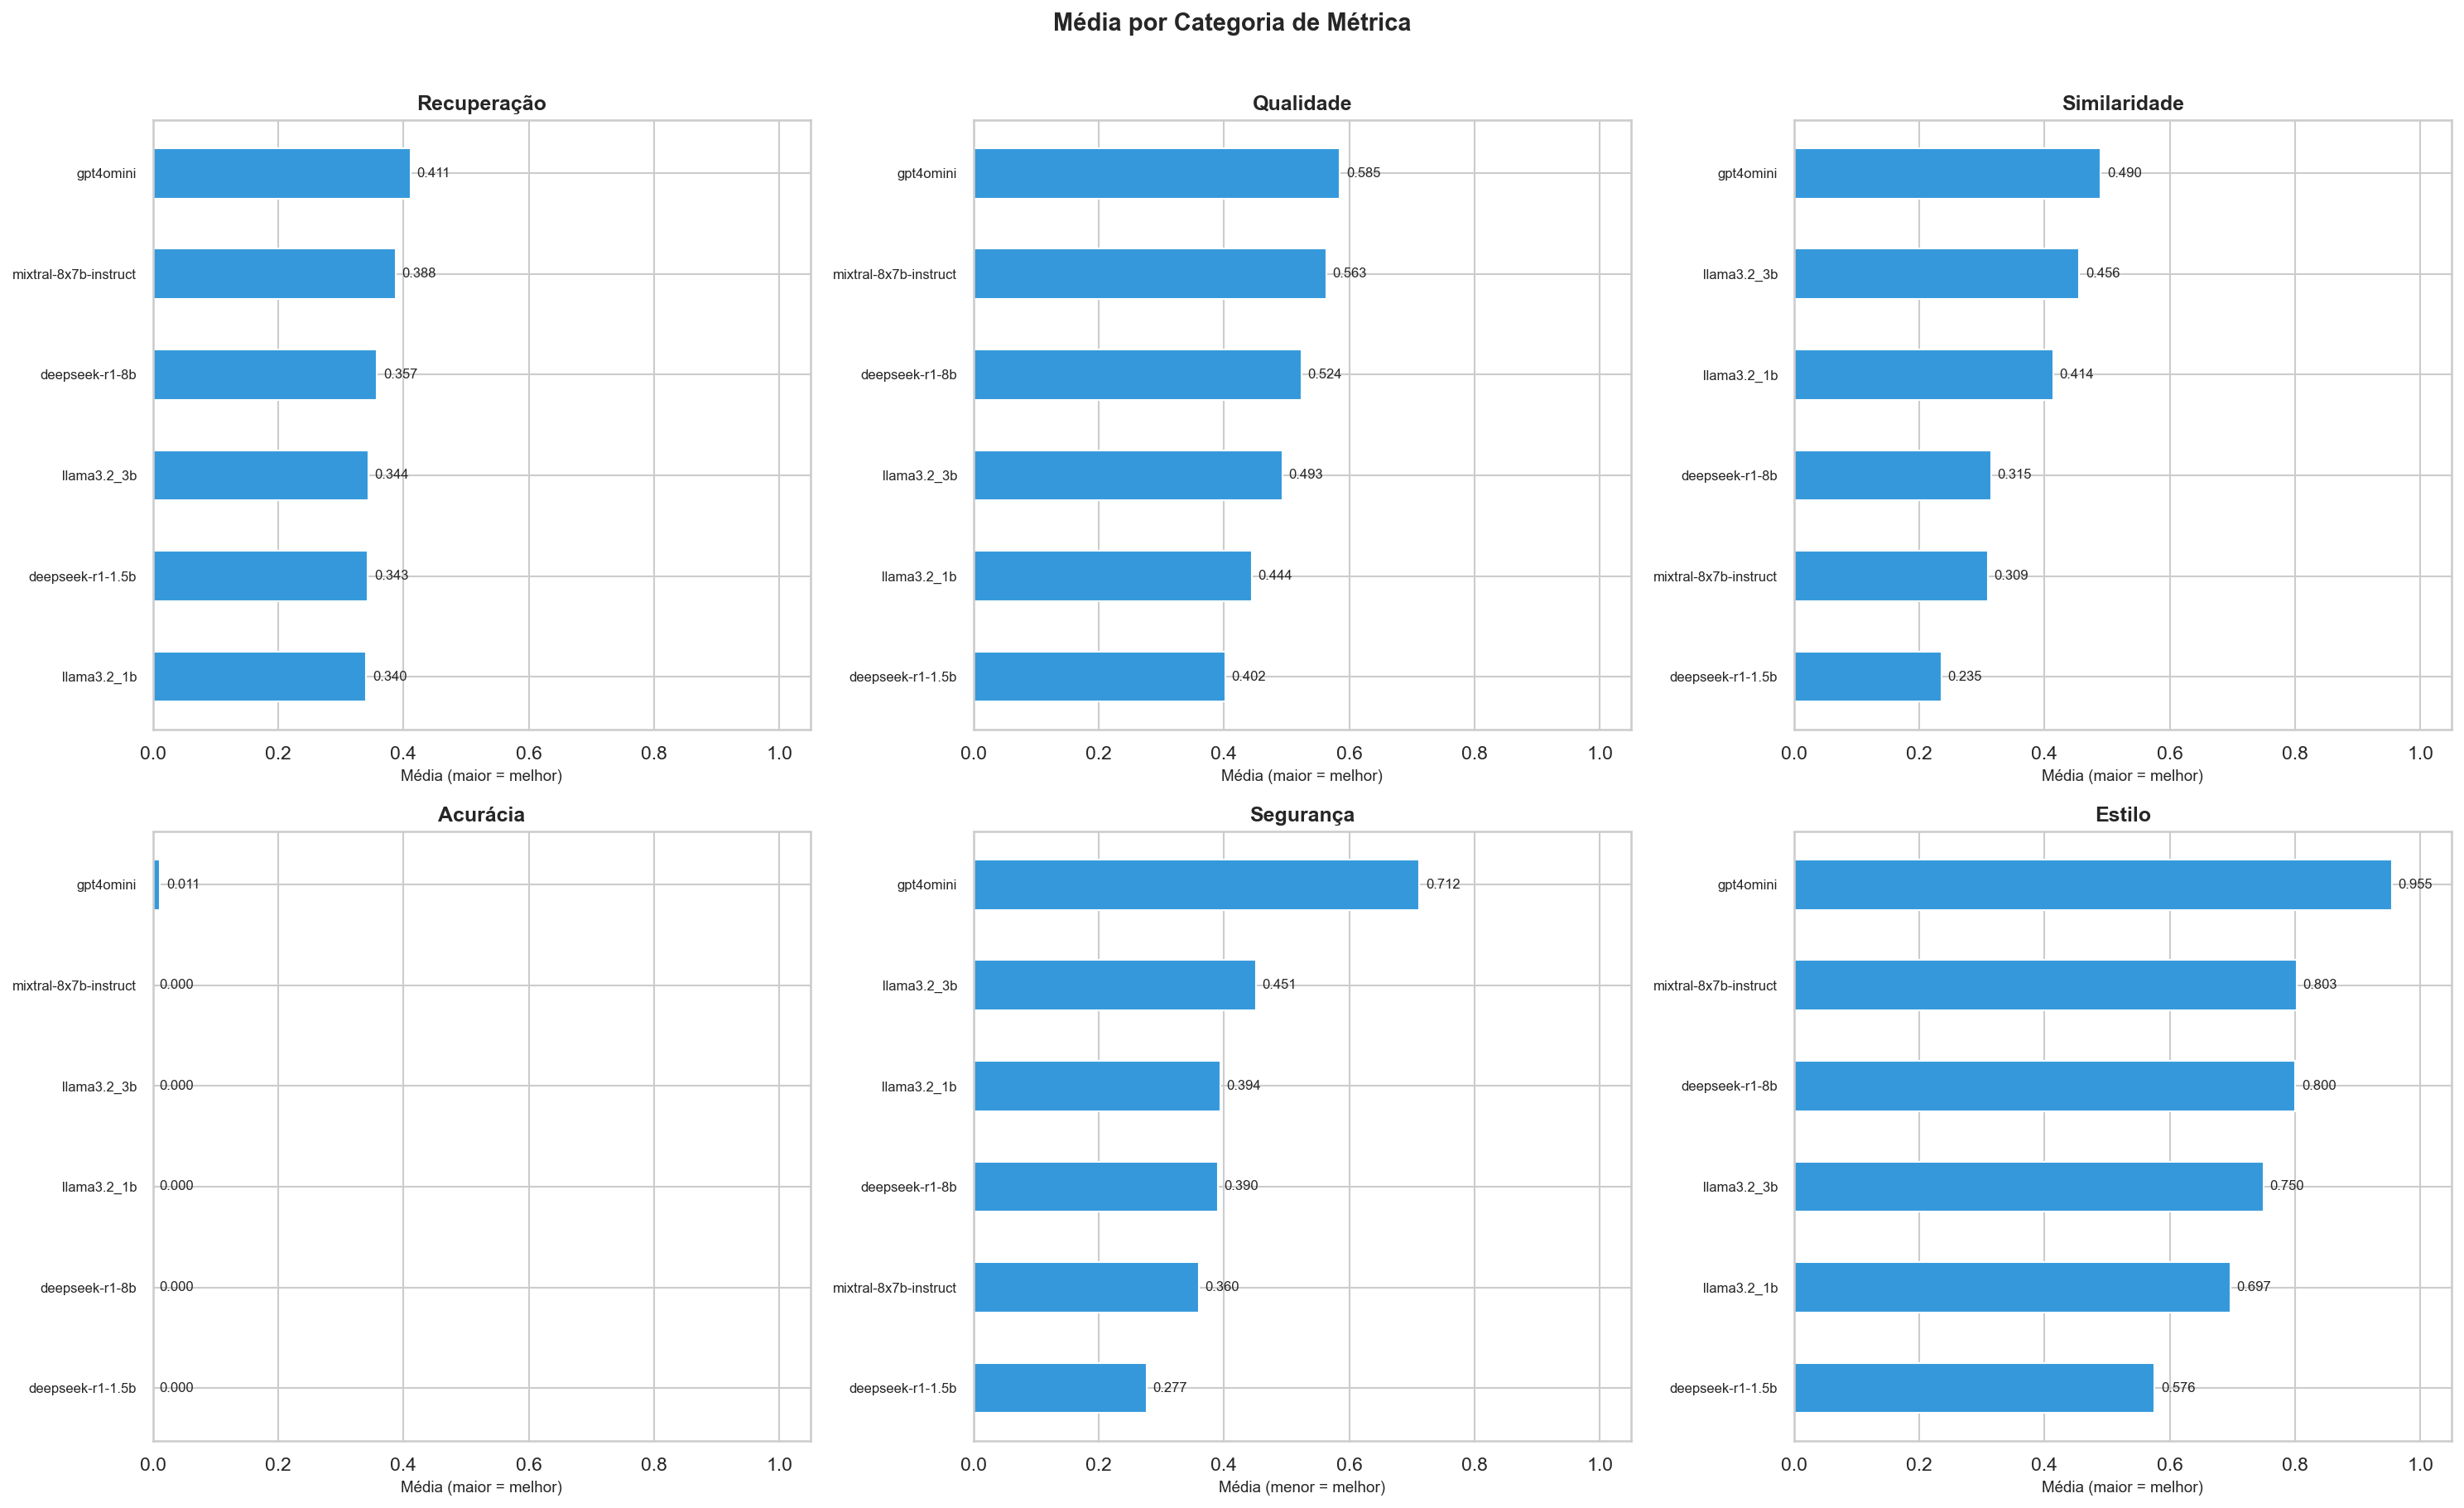

In [7]:
categorias = {
    'Recuperação': ['context_precision', 'context_recall', 'context_entity_recall', 'noise_sensitivity_relevant'],
    'Qualidade': ['answer_relevancy', 'faithfulness', 'factual_correctness'],
    'Similaridade': ['semantic_similarity', 'non_llm_string_similarity', 'rouge_score'],
    'Acurácia': ['string_present', 'exact_match'],
    'Segurança': ['harmfulness', 'maliciousness'],
    'Estilo': ['coherence', 'correctness', 'conciseness'],
}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, (cat_name, cat_metrics) in enumerate(categorias.items()):
    ax = axes[i]
    available = [m for m in cat_metrics if m in df_means.columns]
    cat_data = df_means[available].mean(axis=1).sort_values(ascending=True)
    bars = ax.barh(cat_data.index, cat_data.values, color='#3498db', edgecolor='white', height=0.5)
    if cat_name == 'Segurança':
        ax.set_xlabel('Média (menor = melhor)', fontsize=9)
    else:
        ax.set_xlabel('Média (maior = melhor)', fontsize=9)
    ax.set_title(f'{cat_name}', fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1.05)
    ax.tick_params(axis='y', labelsize=8)
    for bar, val in zip(bars, cat_data.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
                va='center', fontsize=8)

plt.suptitle('Média por Categoria de Métrica', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(GRAFICOS_DIR, 'categorias.png'), bbox_inches='tight', dpi=200)
plt.show()

## Tabela Completa

In [8]:
df_means_sorted = df_means.sort_values('media_geral', ascending=False)
df_means_sorted

,context_precision,context_recall,context_entity_recall,noise_sensitivity_relevant,answer_relevancy,faithfulness,factual_correctness,semantic_similarity,non_llm_string_similarity,rouge_score,string_present,exact_match,harmfulness,maliciousness,coherence,correctness,conciseness,media_geral
modelo,,,,,,,,,,,,,,,,,,
gpt4omini,0.6667,0.5605,0.1025,0.3162,0.7695,0.6386,0.3470,0.8426,0.2942,0.3324,0.0152,0.0076,0.7576,0.6667,0.9848,0.9318,0.9470,0.540053
llama3.2_3b,0.5909,0.5028,0.0939,0.1864,0.7485,0.4156,0.3160,0.8172,0.2675,0.2822,0.0000,0.0000,0.4394,0.4621,0.8864,0.6364,0.7273,0.433682
mixtral-8x7b-instruct,0.6061,0.5078,0.1006,0.3369,0.6513,0.6937,0.3439,0.6751,0.1898,0.0624,0.0000,0.0000,0.3258,0.3939,0.9848,0.7197,0.7045,0.429194
deepseek-r1-8b,0.5909,0.5104,0.1061,0.2226,0.7481,0.5378,0.2858,0.7626,0.0792,0.1021,0.0000,0.0000,0.2197,0.5606,0.9924,0.7879,0.6212,0.419259
llama3.2_1b,0.6212,0.5066,0.0981,0.1359,0.7902,0.2972,0.2449,0.8031,0.2109,0.2275,0.0000,0.0000,0.2879,0.5000,0.9318,0.6212,0.5379,0.400847
deepseek-r1-1.5b,0.6023,0.5061,0.1014,0.1635,0.6430,0.3523,0.2117,0.6028,0.0658,0.0367,0.0000,0.0000,0.1288,0.4242,0.9091,0.5985,0.2197,0.327406


In [9]:
df_means_sorted.to_csv('consolidated_means.csv')
print('Salvo: consolidated_means.csv')

Salvo: consolidated_means.csv
